<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_9_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Notebook: Clustering and Dimensionality Reduction

**You do not need to submit this Notebook.** It is for practice only.

## Introduction

This notebook explores clustering algorithms (K-Means, DBSCAN, and AgglomerativeClustering) and the Principal Component Analysis dimensionality reduction technique using the Iris dataset.

### Goal
Apply clustering methods to discover patterns in data, compare their performance using Silhouette scores, and investigate how dimensionality reduction affects clustering results.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import cluster
from sklearn import datasets
from sklearn import decomposition
from sklearn import metrics
from sklearn import preprocessing

In [2]:
seed = 42

## Revisiting the Iris Dataset

As introduced in a previous module, the Iris dataset contains measurements of 150 iris flowers from three species. Each flower has four features: sepal length, sepal width, petal length, and petal width. This time, we will be using the dataset to explore clustering algorithms.

## Load and Explore the Data

In [3]:
iris = datasets.load_iris(as_frame=True)
X = iris.data
y = iris.target
X.shape, y.shape

((150, 4), (150,))

In [4]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


## Preparing the Data

The Iris dataset does not contain null values or categorical features, so it only needs to be scaled here.

In [6]:
X_scaled = pd.DataFrame(
    preprocessing.StandardScaler().fit_transform(X),
    columns=X.columns
)

X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## Clustering with Original Features

We will apply three clustering algorithms: K-Means, DBSCAN, and AgglomerativeClustering.

### Train Models

In [7]:
kmeans = cluster.KMeans(n_clusters=3, random_state=seed, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

In [8]:
dbscan = cluster.DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

In [9]:
agglom = cluster.AgglomerativeClustering(n_clusters=3)
labels_agglom = agglom.fit_predict(X_scaled)

### Compare Silhouette Scores

Silhouette scores measure how well-separated the clusters are. Scores range from -1 to 1, with higher values indicating better-defined clusters.

In [10]:
pd.Series({
  "K-Means": metrics.silhouette_score(X_scaled, labels_kmeans),
  "DBSCAN": metrics.silhouette_score(X_scaled, labels_dbscan),
  "Agglomerative": metrics.silhouette_score(X_scaled, labels_agglom)
}).rename("score").sort_values(ascending=False)

,score
K-Means,0.459948
Agglomerative,0.446689
DBSCAN,0.356516


### Visualize Clusters

Here we visualize the clusters twice per model using the pairs of petal features and then the pairs of sepal features.

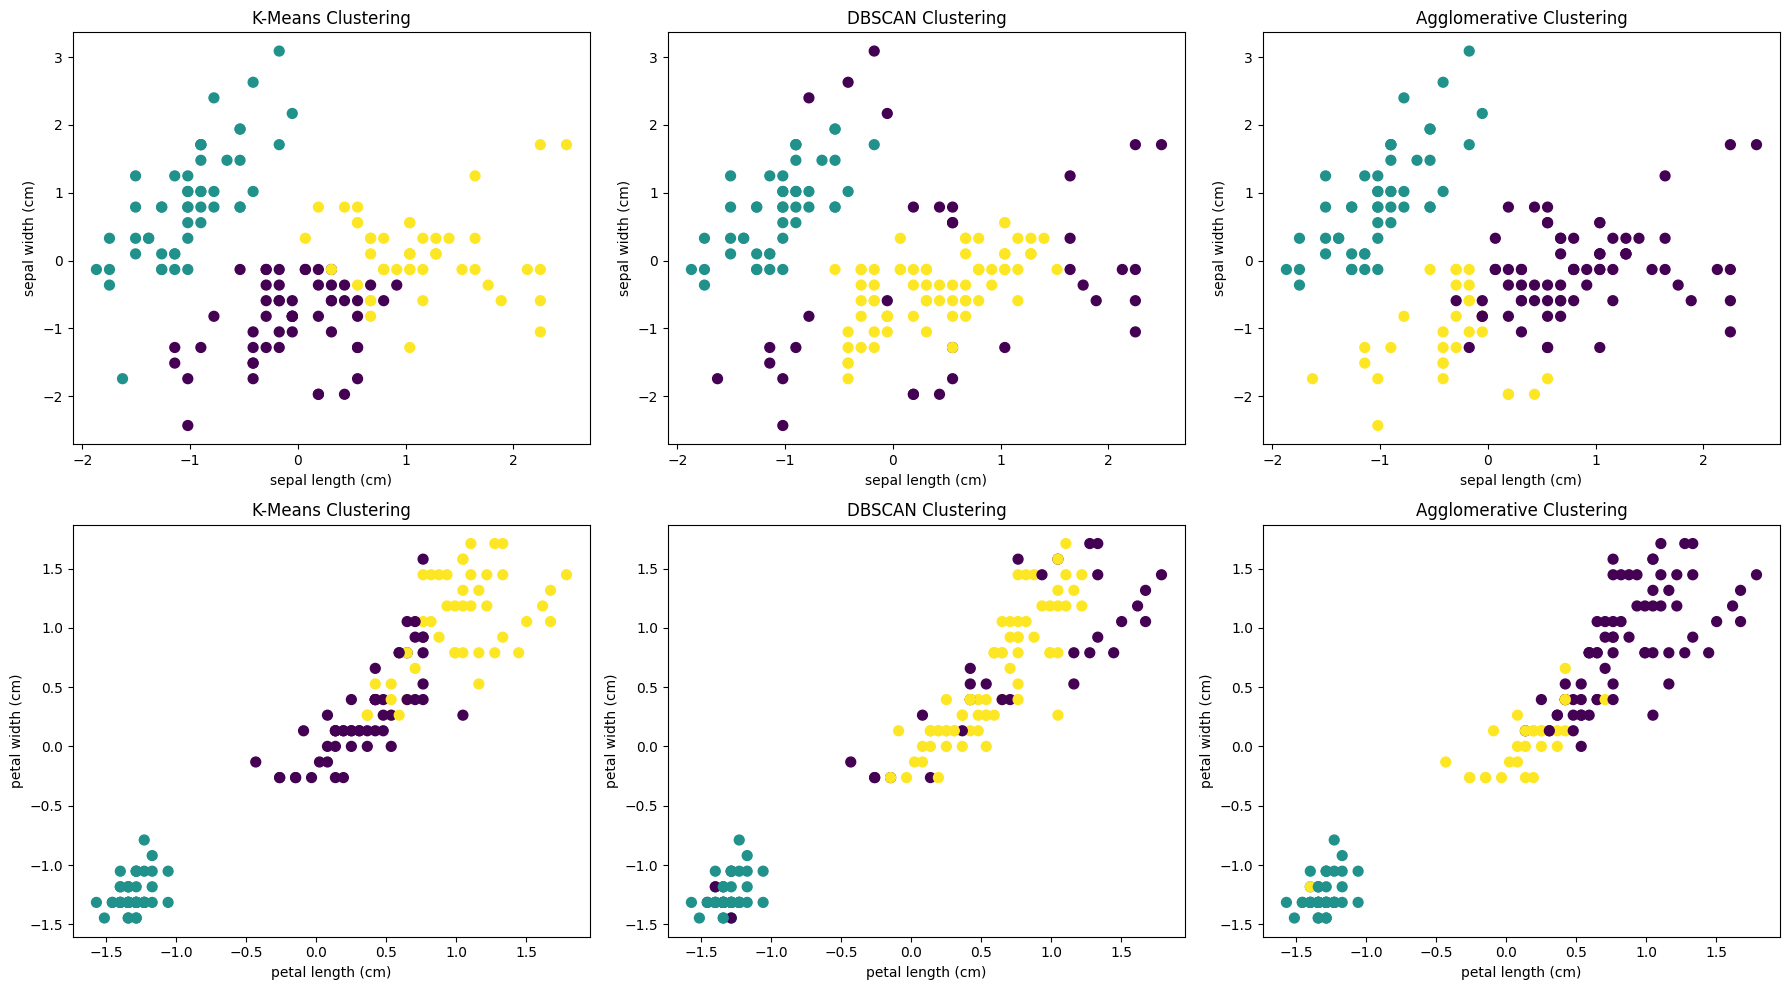

In [11]:
label_map = {
  "K-Means": labels_kmeans,
  "DBSCAN": labels_dbscan,
  "Agglomerative": labels_agglom
}

n_rows = 2
fig, axes = plt.subplots(n_rows, len(label_map), figsize=(18, 10))

for row_i in range(n_rows):
    feat_xaxis = row_i * 2
    feat_yaxis = feat_xaxis + 1
    for col_i, (title, labels) in enumerate(label_map.items()):
        ax = axes[row_i, col_i] if n_rows > 1 else axes[i]
        ax.scatter(
            X_scaled.iloc[:, feat_xaxis],
            X_scaled.iloc[:, feat_yaxis],
            c=labels,
            cmap="viridis",
            s=50
        )
        ax.set_title(f"{title} Clustering")
        ax.set_xlabel(X_scaled.columns[feat_xaxis])
        ax.set_ylabel(X_scaled.columns[feat_yaxis])

plt.tight_layout()
plt.show()

#### Self-Check

Is there one model that appears to have performed better than the others? Do the visualizations align with Silhouette scores?

## Clustering with Principal Component Analysis

Principal Component Analysis reduces the dimensionality of the data while preserving as much variance as possible. We reduce to 2 components for visualization and clustering.

In [12]:
pca = decomposition.PCA(n_components=2, random_state=seed)
X_pca = pd.DataFrame(
    pca.fit_transform(X_scaled),
    columns=["PC1", "PC2"]
)
X_pca.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


### Train Models

In [13]:
kmeans_pca = cluster.KMeans(n_clusters=3, random_state=seed, n_init=10)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca)

In [14]:
dbscan_pca = cluster.DBSCAN(eps=0.5, min_samples=5)
labels_dbscan_pca = dbscan_pca.fit_predict(X_pca)

In [15]:
agglom_pca = cluster.AgglomerativeClustering(n_clusters=3)
labels_agglom_pca = agglom_pca.fit_predict(X_pca)

### Compare Silhouette Scores

In [16]:
pd.Series({
  "K-Means": metrics.silhouette_score(X_pca, labels_kmeans_pca),
  "DBSCAN": metrics.silhouette_score(X_pca, labels_dbscan_pca),
  "Agglomerative": metrics.silhouette_score(X_pca, labels_agglom_pca)
}).rename("score").sort_values(ascending=False)

,score
DBSCAN,0.524531
Agglomerative,0.511060
K-Means,0.509168


### Visualize Clusters

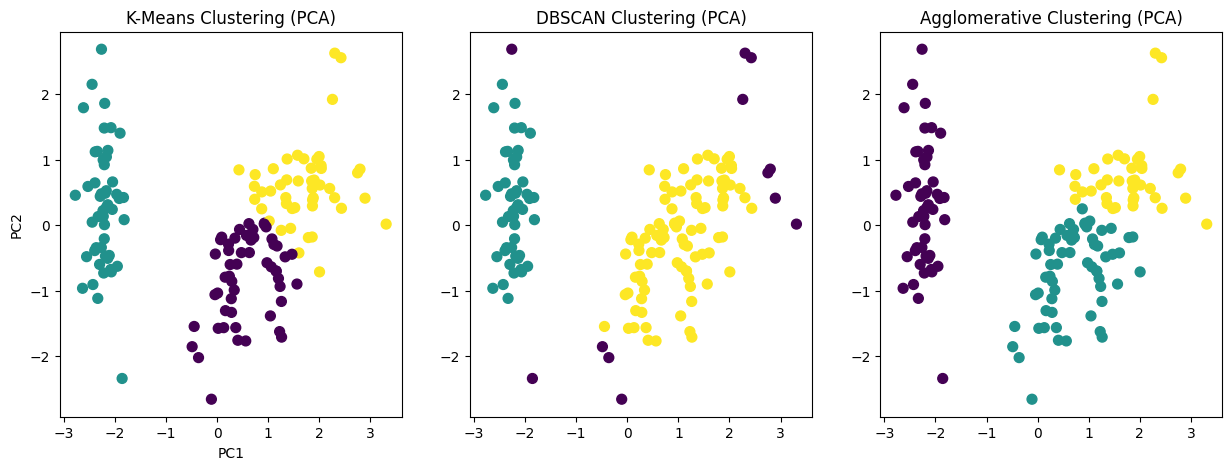

In [17]:
label_map = {
    "K-Means": labels_kmeans_pca,
    "DBSCAN": labels_dbscan_pca,
    "Agglomerative": labels_agglom_pca
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (title, labels) in enumerate(label_map.items()):
    axes[i].scatter(
        X_pca["PC1"],
        X_pca["PC2"],
        c=labels,
        cmap="viridis",
        s=50
    )
    axes[i].set_title(f"{title} Clustering (PCA)")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")

#### Self-Check

Is there a model that did better after PCA than with the original features?

## Summary

In this notebook, you practiced:

- Applying three clustering algorithms: K-Means, DBSCAN, and AgglomerativeClustering
- Comparing clustering performance using Silhouette scores
- Visualizing clusters in 2D space
- Using PCA for dimensionality reduction
- Observing how dimensionality reduction affects clustering results

### Self-Check

- How did dimensionality reduction affect the Silhouette scores for each algorithm?
- Which clustering algorithm performed best on each dataset?
- What hyperparameters could you adjust in each clustering algorithm to improve results?